In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import graphviz

#modelos
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

#métricas
from sklearn.metrics import r2_score
from sklearn.metrics import max_error
from sklearn.metrics import explained_variance_score
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
!wget -O saneamento https://drive.usercontent.google.com/download?id=1ZJBoOH6aX7UFTkvhVtVpVKqS3VCG3XRZ&export=download&authuser=0

--2024-10-29 19:00:51--  https://drive.usercontent.google.com/download?id=1ZJBoOH6aX7UFTkvhVtVpVKqS3VCG3XRZ
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.163.132, 2607:f8b0:4004:c1b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.163.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 59266190 (57M) [application/octet-stream]
Saving to: ‘saneamento’

saneamento          100%[===================>]  56.52M  48.1MB/s    in 1.2s    

2024-10-29 19:00:57 (48.1 MB/s) - ‘saneamento’ saved [59266190/59266190]



In [ ]:
dataset = pd.read_csv('saneamento')
colunas_desejadas = ['populacao_atendida_agua', 'populacao_atentida_esgoto', 'extensao_rede_agua', 'volume_agua_tratada_eta', 'volume_agua_fluoretada','volume_agua_produzido', 'volume_agua_consumido']
dados_selecionados = dataset[colunas_desejadas]

df = dados_selecionados.dropna()
df = df[(df != 0).all(axis=1)]

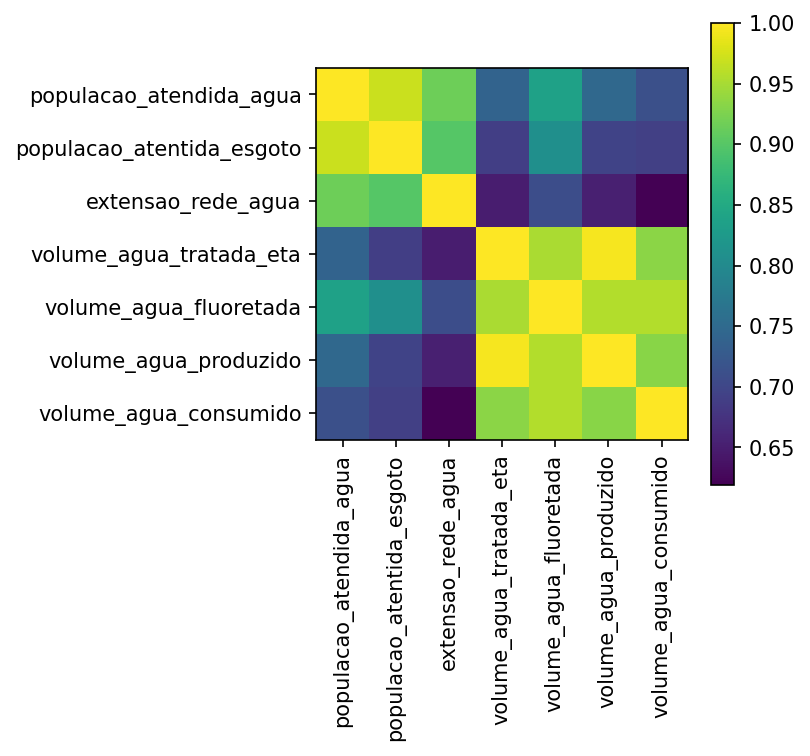

In [ ]:
corr = df.corr() # method = 'pearson'

plt.figure(figsize = (4, 4), dpi = 150)
plt.xticks(range(np.size(colunas_desejadas)), labels = corr.columns,rotation=90)
plt.yticks(range(np.size(colunas_desejadas)), labels = corr.columns)

plt.imshow(corr)
plt.colorbar()
plt.show()

# 1. Regressão linear

In [ ]:
features = ['volume_agua_produzido', 'volume_agua_fluoretada', 'volume_agua_tratada_eta']
X = np.array(df[features])
Y = np.array(df['volume_agua_consumido'])

# divisão dos conjuntos de treino (80%) e teste (20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size = 0.8, random_state = 42)
pd.core.frame.DataFrame(Y_train)

,0
0,100.17
1,1183.00
2,399.81
3,579.90
4,876.28
...,...
16733,6074.78
16734,1925.71
16735,294.26
16736,77.04


In [ ]:
pd.core.frame.DataFrame(Y)

,0
0,1952.68
1,518.40
2,641.00
3,147548.26
4,1500.81
...,...
20918,11.60
20919,140.30
20920,309.20
20921,428.89


In [ ]:
hipotese = LinearRegression() # y = t0 + t1*x
hipotese.fit(X_train, Y_train) # treinamento do modelo

print(hipotese.intercept_, hipotese.coef_)

-461.93098756197014 [0.00935134 0.50470881 0.2451983 ]


In [ ]:
(X_train @ hipotese.coef_.T).shape

(16738,)

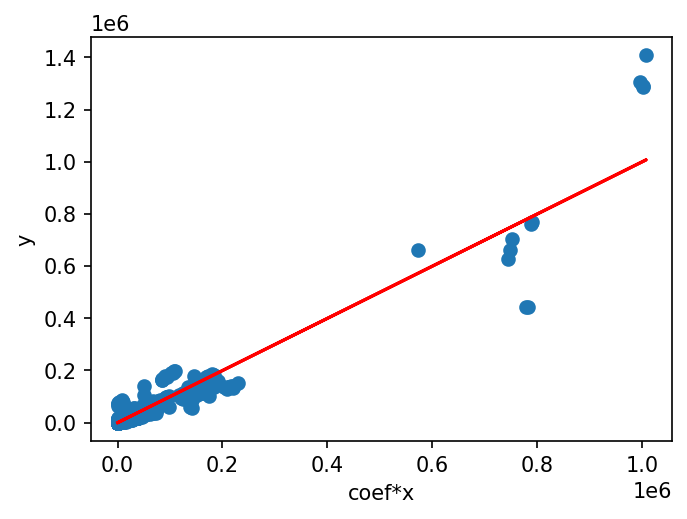

In [ ]:
#várias features
plt.figure(figsize = (5, 3.5), dpi = 150)

id = 0

plt.ylabel('y')
plt.xlabel('coef*x')

X_plt = X_train @ hipotese.coef_.T
Y_plt = Y_train

model_x = X_plt
model_y = hipotese.intercept_ + X_plt

plt.scatter(X_plt, Y_plt)
plt.plot(model_x, model_y, 'r-')
plt.show()

In [ ]:
hipotese.coef_.T

array([0.00935134, 0.50470881, 0.2451983 ])

In [ ]:
Y_pred = hipotese.predict(X_test)
print("Coeficiente de determinação R2 =", r2_score(Y_test, Y_pred))
print("Erro Absoluto Médio =", mean_absolute_error(Y_test, Y_pred))
print("Erro Absoluto Mediano =", median_absolute_error(Y_test, Y_pred))

Coeficiente de determinação R2 = 0.9084972908014237
Erro Absoluto Médio = 1714.675175331996
Erro Absoluto Mediano = 477.6921427844843


# 2. Máquinas Vetores de Suporte (SVM)

In [ ]:
X = np.array(df[['volume_agua_produzido', 'volume_agua_fluoretada', 'volume_agua_tratada_eta']])
y = np.array(df['volume_agua_consumido'])

**Usando LinearSVR (não foi possivel usar o SVR com kernel linear, provavelmente por conta do tamanho do conjunto de dados)**

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


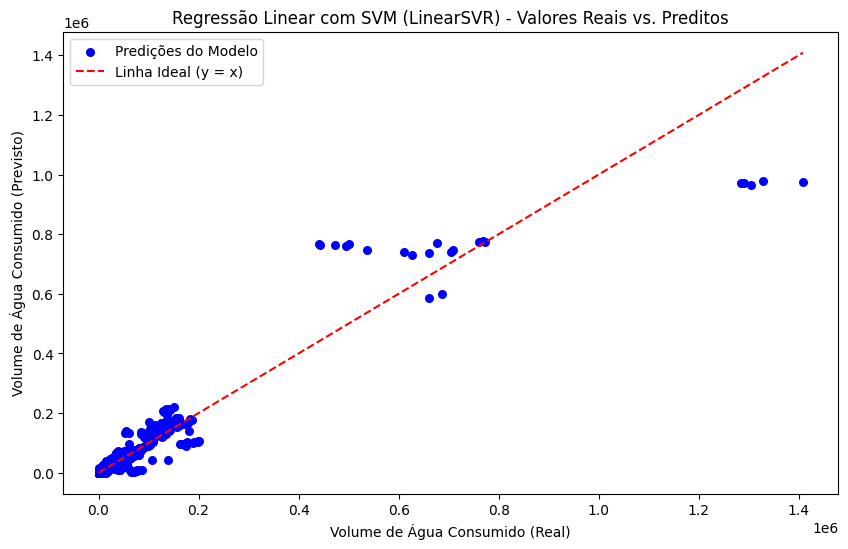

Coeficiente de determinação R2 = 0.9179066897133268
Erro Absoluto Médio(MAE) = 1233.7450410179515
Erro Absoluto Mediano(MedAE) = 111.9095183876488


In [ ]:
epsilon_value = 0.5
linear_svr = LinearSVR(C=100, epsilon=epsilon_value, random_state = 42)
linear_svr.fit(X, y)
y_pred = linear_svr.predict(X)

#valores reais vs. valores preditos
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color="blue", s=30, label="Predições do Modelo")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", label="Linha Ideal (y = x)")

plt.xlabel("Volume de Água Consumido (Real)")
plt.ylabel("Volume de Água Consumido (Previsto)")
plt.title("Regressão Linear com SVM (LinearSVR) - Valores Reais vs. Preditos")
plt.legend()
plt.show()

print("Coeficiente de determinação R2 =", r2_score(y, y_pred))
print("Erro Absoluto Médio(MAE) =", mean_absolute_error(y, y_pred))
print("Erro Absoluto Mediano(MedAE) =", median_absolute_error(y, y_pred))

# 3. Árvore de Decisão

In [ ]:
X = np.array(df[['volume_agua_produzido']])
y = np.array(df['volume_agua_consumido'])

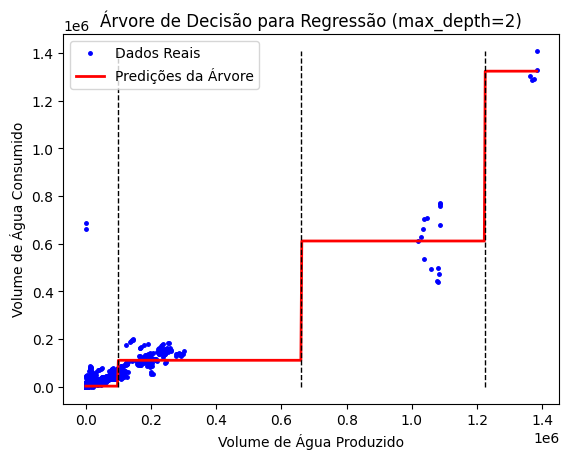

Métricas para max_depth=2:
Coeficiente de Determinação R² = 0.8767453467902903
Erro Absoluto Médio (MAE) = 4053.1666443417043
Erro Máximo = 684052.5705976712



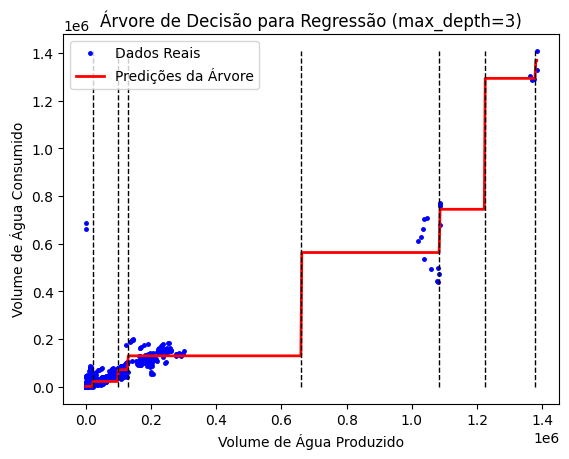

Métricas para max_depth=3:
Coeficiente de Determinação R² = 0.9172928523821826
Erro Absoluto Médio (MAE) = 2631.174077936322
Erro Máximo = 685316.2351797378



In [ ]:
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg1.fit(X, y)
tree_reg2.fit(X, y)

def plot_decision_tree_regression(tree_reg, X, y, max_depth):
    x1 = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)

    # Plot dos pontos reais e das previsões da árvore
    plt.plot(X, y, "b.", label="Dados Reais", markersize=5)
    plt.plot(x1, y_pred, "r-", linewidth=2, label="Predições da Árvore")
    plt.xlabel("Volume de Água Produzido")
    plt.ylabel("Volume de Água Consumido")
    plt.title(f"Árvore de Decisão para Regressão (max_depth={max_depth})")

    # Marcar as divisões de decisão
    plt.vlines(tree_reg.tree_.threshold[tree_reg.tree_.threshold != -2],
               y.min(), y.max(), colors="k", linestyles="--", linewidth=1)

    plt.legend()
    plt.show()

    # predições
    y_train_pred = tree_reg.predict(X)

    # métricas
    r2 = r2_score(y, y_train_pred)
    mae = mean_absolute_error(y, y_train_pred)
    medae = median_absolute_error(y, y_train_pred)
    mse = mean_squared_error(y, y_train_pred)
    max_error_value = max_error(y, y_train_pred)

    print(f"Métricas para max_depth={max_depth}:")
    print(f"Coeficiente de Determinação R² = {r2}")
    print(f"Erro Absoluto Médio (MAE) = {mae}")
    print(f"Erro Máximo = {max_error_value}\n")

# max_depth=2
plot_decision_tree_regression(tree_reg1, X, y, max_depth=2)

# max_depth=3
plot_decision_tree_regression(tree_reg2, X, y, max_depth=3)